In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import scipy.io
from neuralop.models import FNO2d

In [2]:
def coriolis_force(lat):
    omega = 2 * np.pi / (24 * 60 * 3600)
    f = 2 * omega * np.sin(lat)
    return f

In [3]:
nu = 10**(-3)

In [4]:
N_train = 5000

data = scipy.io.loadmat('navier_Stokes.mat')
U_star = data['U_star']
X_star = data['X_star']
t_star = data['t']
p_star = data['p_star']

U = U_star[:, 0, :]
V = U_star[:, 1, :]

x = X_star[:, 0].reshape(50, 100)
y = X_star[:, 1].reshape(50, 100)

X = np.expand_dims(x, axis=0)  # Add a new axis at the beginning, shape (1, 50, 100)
Y = np.expand_dims(y, axis=0)  # Add a new axis at the beginning, shape (1, 50, 100)
T = np.expand_dims(t_star, axis=(1))  # Shape (200, 1)

XX = np.tile(X, (t_star.shape[0], 1, 1))  # Tile along the new axis to get shape (200, 50, 100)
YY = np.tile(Y, (t_star.shape[0], 1, 1))  # Tile along the new axis to get shape (200, 50, 100)
TT = np.tile(T, (1, 50, 100))  # Shape (200, 50, 100)

x_train = torch.tensor(XX, dtype=torch.float32, requires_grad=True)
y_train = torch.tensor(YY, dtype=torch.float32, requires_grad=True)
t_train = torch.tensor(TT, dtype=torch.float32, requires_grad=True)
u_train = torch.tensor(U.reshape(200, 50, 100), dtype=torch.float32)
v_train = torch.tensor(V.reshape(200, 50, 100), dtype=torch.float32)
p_train = torch.tensor(p_star.reshape(200, 50, 100), dtype=torch.float32)

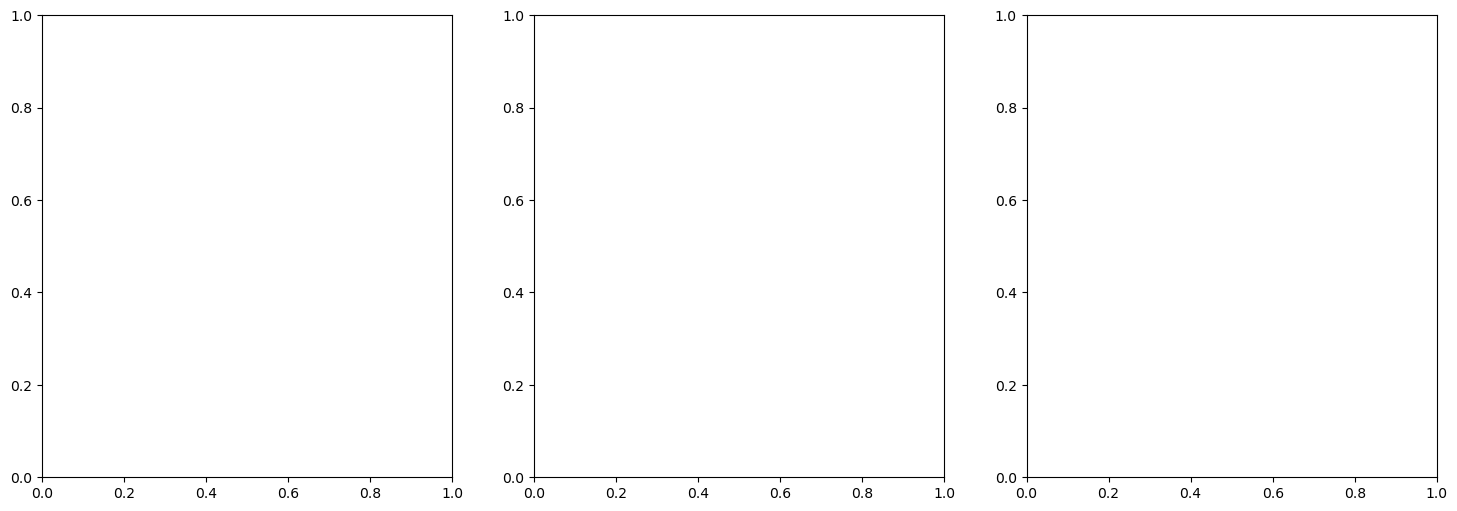

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

def update(frame):
    ax[0].clear()
    ax[1].clear()
    ax[2].clear()
    
    U_plot = U_star[:, 0, frame].reshape(50, 100)
    V_plot = U_star[:, 1, frame].reshape(50, 100)
    P_plot = p_star[:, frame].reshape(50, 100)
    
    ax[0].contourf(X_plot, Y_plot, U_plot, levels = 20, cmap='jet') # Levels = 20 is necessary cuz gives error that contour lines not increasing
    ax[1].contourf(X_plot, Y_plot, V_plot, levels = 20, cmap='jet')
    ax[2].contourf(X_plot, Y_plot, P_plot, levels = 20, cmap='jet')
     
    ax[0].set_title(f'U velocity at t={t_star[frame][0]:.2f}')
    ax[1].set_title(f'V velocity at t={t_star[frame][0]:.2f}')
    ax[2].set_title(f'Pressure at t={t_star[frame][0]:.2f}')
    ax[0].set_xlabel('x')
    ax[0].set_ylabel('y')
    ax[1].set_xlabel('x')
    ax[1].set_ylabel('y')
    ax[2].set_xlabel('x')
    ax[2].set_ylabel('y')

ani = animation.FuncAnimation(fig, update, frames=t_star.shape[0], interval=1)
#ani.save('navier_stokes_animation_true.gif') # Same graph when plot the test data
plt.show()

In [6]:
def loss_phys(f_x, f_y, c):
    return torch.mean((f_x - 0)**2 + (f_y - 0)**2 + (c - 0)**2)

In [7]:
def loss_data(u, v, p): 
    return torch.mean((u - u_train)**2 + (v - v_train)**2 + (p - p_train)**2)

In [8]:
def function(x, y, t):
    predict = model(torch.stack((x, y, t), axis = 1)) # Allows x, y, and t to be in the computational graph instead of creating training_data
    psi = predict[:, 0, :, :]
    p = predict[:, 1, :, :]
    
    u = torch.autograd.grad(psi, y, grad_outputs=torch.ones_like(psi), create_graph=True)[0]
    v = -1 * torch.autograd.grad(psi, x, grad_outputs=torch.ones_like(psi), create_graph=True)[0]

    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]

    v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, grad_outputs=torch.ones_like(v_y), create_graph=True)[0]

    ssh_x = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    ssh_y = torch.autograd.grad(p, y, grad_outputs=torch.ones_like(p), create_graph=True)[0]

    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    v_t = torch.autograd.grad(v, t, grad_outputs=torch.ones_like(v), create_graph=True)[0]

    f_x = u_t + u * u_x + v * u_y + p - nu * (u_xx + u_yy)
    f_y = v_t + u * v_x + v * v_y + p - nu * (v_xx + v_yy)

    c = u_x + v_y

    return u, v, p, f_x, f_y, c

In [9]:
def closure():
    optimizer.zero_grad()
    u_pred, v_pred, p_pred, f_x, f_y, c = function(x_train, y_train, t_train)
    loss = loss_data(u_pred, v_pred, p_pred) + loss_phys(f_x, f_y, c) 
    loss.backward()
    return loss

In [10]:
# Training function
def train(model, optimizer, num_epochs = 500):
    prev_loss = float('inf')  
    for epoch in range(1, num_epochs + 1):
        loss = optimizer.step(closure) # This is for LBFGS
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item()}')
        if loss.item() >= prev_loss:
            break # Stop iteration if loss isn't decreasing
        prev_loss = loss.item()

In [ ]:
# # This is for 3D
# model = FNO(
#     n_modes=(16, 16, 16),      
#     in_channels=3,            
#     hidden_channels=32,       
#     out_channels=3,            
#     n_layers=4
# )

try:
    torch.cuda.synchronize()  # Force synchronization to catch errors
    device = torch.device('cuda:0')
    # This is for 2D
    model = FNO2d(
        n_modes_width=2,
        n_modes_height=2,
        in_channels=3,
        hidden_channels=2,
        out_channels=3,
        n_layers=1
    )
except RuntimeError as e:
    print(f"RuntimeError caught: {e}")
except Exception as e:
    print(f"Other exception caught: {e}")
# LBFGS optimizer best for handling second derivative information and small datasets
# requires a closure() to perform the loss function multiple times, and be consistent
# optimizer = optim.LBFGS(model.parameters(), lr = 0.001)
optimizer = optim.Adam(model.parameters(), lr = 0.001)

# Train the model
train(model, optimizer)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

u_pred, v_pred, p_pred, _ , _, _ = function(x_test, y_test, t_test * t_star[0][0])

U_plot = u_pred.detach().numpy().reshape(50, 100)
V_plot = v_pred.detach().numpy().reshape(50, 100)
P_plot = p_pred.detach().numpy().reshape(50, 100)

ax[0].contourf(X_plot, Y_plot, U_plot, cmap='jet')
ax[1].contourf(X_plot, Y_plot, V_plot, cmap='jet')
ax[2].contourf(X_plot, Y_plot, P_plot, cmap='jet')

c1 = ax[0].contourf(X_plot, Y_plot, U_plot, cmap='jet')
c2 = ax[1].contourf(X_plot, Y_plot, V_plot, cmap='jet')
c3 = ax[2].contourf(X_plot, Y_plot, P_plot, cmap='jet')

cb1 = fig.colorbar(c1, ax=ax[0])
cb2 = fig.colorbar(c2, ax=ax[1])
cb3 = fig.colorbar(c3, ax=ax[2])

def update(frame):
    ax[0].clear()
    ax[1].clear()
    ax[2].clear()

    u_pred, v_pred, p_pred, _ , _, _ = function(x_test, y_test, t_test * t_star[frame][0])
    
    U_plot = u_pred.detach().numpy().reshape(50, 100)
    V_plot = v_pred.detach().numpy().reshape(50, 100)
    P_plot = p_pred.detach().numpy().reshape(50, 100)

    ax[0].contourf(X_plot, Y_plot, U_plot, cmap='jet')
    ax[1].contourf(X_plot, Y_plot, V_plot, cmap='jet')
    ax[2].contourf(X_plot, Y_plot, P_plot, cmap='jet')
    
    ax[0].set_title(f'U velocity at t={t_star[frame][0]:.2f}')
    ax[1].set_title(f'V velocity at t={t_star[frame][0]:.2f}')
    ax[2].set_title(f'Pressure at t={t_star[frame][0]:.2f}')
    ax[0].set_xlabel('y')
    ax[0].set_ylabel('x')
    ax[1].set_xlabel('y')
    ax[1].set_ylabel('x')
    ax[2].set_xlabel('y')
    ax[2].set_ylabel('x')

ani = animation.FuncAnimation(fig, update, frames=t_star.shape[0], interval=1)
#ani.save('navier_stokes_animation_pred.gif')
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

u_pred, v_pred, p_pred, _ , _ , _ = function(x_test, y_test, t_test * t_star[0][0])

U_plot = ((u_test[:, 0:1] - u_pred.detach().numpy())**2).reshape(50, 100) # [:, frame:frame + 1] to get extra dim. **2 to see differences
V_plot = ((v_test[:, 0:1] - v_pred.detach().numpy())**2).reshape(50, 100)
P_plot = ((p_test[:, 0:1] - p_pred.detach().numpy())**2).reshape(50, 100)

ax[0].contourf(X_plot, Y_plot, U_plot, cmap='jet')
ax[1].contourf(X_plot, Y_plot, V_plot, cmap='jet')
ax[2].contourf(X_plot, Y_plot, P_plot, cmap='jet')

c1 = ax[0].contourf(X_plot, Y_plot, U_plot, cmap='jet')
c2 = ax[1].contourf(X_plot, Y_plot, V_plot, cmap='jet')
c3 = ax[2].contourf(X_plot, Y_plot, P_plot, cmap='jet')

cb1 = fig.colorbar(c1, ax=ax[0])
cb2 = fig.colorbar(c2, ax=ax[1])
cb3 = fig.colorbar(c3, ax=ax[2])

def update(frame):
    ax[0].clear()
    ax[1].clear()
    ax[2].clear()

    u_pred, v_pred, p_pred, _ , _ , _ = function(x_test, y_test, t_test * t_star[frame][0])

    U_plot = ((u_test[:, frame:frame + 1] - u_pred.detach().numpy())**2).reshape(50, 100) # [:, frame:frame + 1] to get extra dim. **2 to see differences
    V_plot = ((v_test[:, frame:frame + 1] - v_pred.detach().numpy())**2).reshape(50, 100)
    P_plot = ((p_test[:, frame:frame + 1] - p_pred.detach().numpy())**2).reshape(50, 100)
    
    ax[0].contourf(X_plot, Y_plot, U_plot, cmap='jet')
    ax[1].contourf(X_plot, Y_plot, V_plot, cmap='jet')
    ax[2].contourf(X_plot, Y_plot, P_plot, cmap='jet')
     
    ax[0].set_title(f'U velocity at t={t_star[frame][0]:.2f}')
    ax[1].set_title(f'V velocity at t={t_star[frame][0]:.2f}')
    ax[2].set_title(f'Pressure at t={t_star[frame][0]:.2f}')
    ax[0].set_xlabel('y')
    ax[0].set_ylabel('x')
    ax[1].set_xlabel('y')
    ax[1].set_ylabel('x')
    ax[2].set_xlabel('y')
    ax[2].set_ylabel('x')

ani = animation.FuncAnimation(fig, update, frames=t_star.shape[0], interval=1)
#ani.save('navier_stokes_animation_residual.gif')
plt.show()